In [1]:
rm(list = ls())
PHYLOGWAS_ROOT <- Sys.getenv("PHYLOGWAS_ROOT", unset = "/workdir/sh2246/p_phyloGWAS")
library(data.table)
library(tidyverse)
library(parallel)
library(patchwork)
library(pheatmap)
library(ggplot2)
library(ggridges)
library(ape)
library(ggtree)
library(geiger)
library(taxize)

── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::transpose()   masks da

## data input

In [ ]:
# metadata
metadata = read.delim(file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_filtered_2025.08.28.tsv"),header = T)
rownames(metadata) = metadata$assemblyID

# rhizome traits
rhizomeDat = data.table::fread(file.path(PHYLOGWAS_ROOT, "data/grassBase_cleaned_rhizome.txt"),header = T,data.table = F)
rhizomeDat = rhizomeDat[,c(2,1102)]

metadata = merge(metadata,rhizomeDat,by = "assemblyID",all.x = T)
metadata$pacbio = as.factor(grepl("pacbio",metadata$technology,ignore.case = T))
metadata$compdup = metadata$complete+metadata$duplicated

# phyloK
phyloKMat <- read.table(file.path(PHYLOGWAS_ROOT, "output/phyloK_728Poaceae_astral_20250407.txt"))
colnames(phyloKMat) <- rownames(phyloKMat)

# envData
envData = read.table(file.path(PHYLOGWAS_ROOT, "output/envData_707Poaceae_20250804.txt"))
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"

commonID = intersect(metadata$assemblyID,envDf$assemblyID)

## quality check on premature stop codon occurrence and frameshift mutations

In [2]:
PMS = fread(file.path(PHYLOGWAS_ROOT, "output/combined_PMS_20250421.txt"),data.table = F)
colnames(PMS) = c("seqID","PMS","AAlength")
PMS = PMS[!duplicated(PMS$seqID),]
FS = fread(file.path(PHYLOGWAS_ROOT, "output/frameShiftMutation.txt"),data.table = F)[,c(1,3)]
FS2 = fread(file.path(PHYLOGWAS_ROOT, "output/frameShiftMutation_additionalOGs.txt"),data.table = F)[,c(1,3)]
FS = rbind(FS,FS2)
colnames(FS)[1] = "seqID"

In [26]:
PMSperTaxa = tapply(PMS[,2],limma::strsplit2(PMS[,1],":")[,2],function(x) sum(x)/length(x))
FSperTaxa = tapply(FS[,2],limma::strsplit2(FS[,1],":")[,2],function(x) sum(x)/length(x))

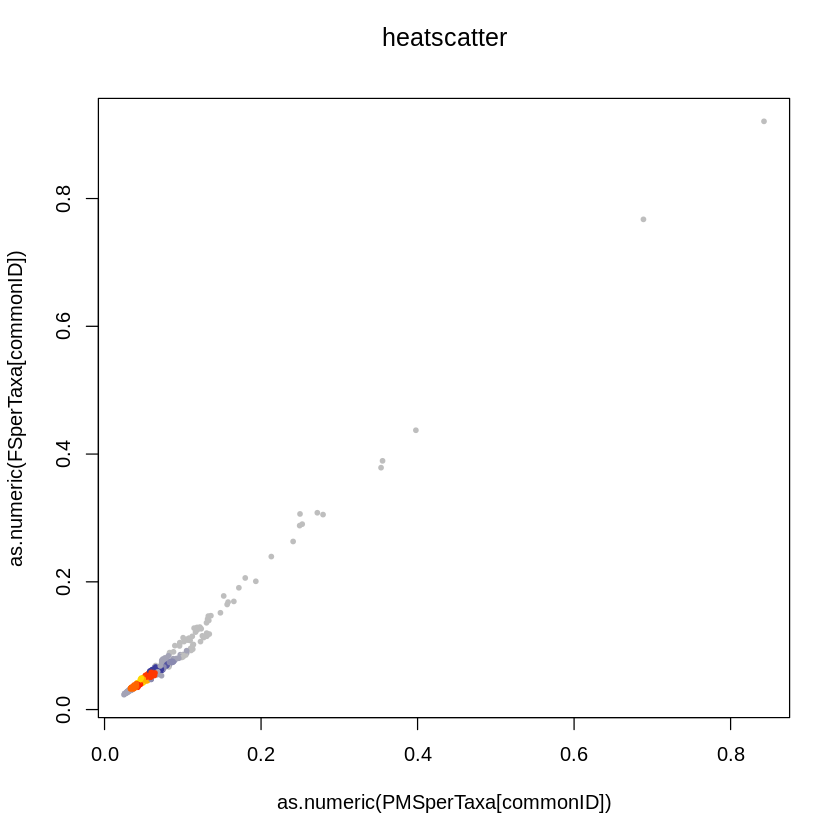

In [35]:
LSD::heatscatter(as.numeric(PMSperTaxa[commonID]),as.numeric(FSperTaxa[commonID]))

In [27]:
filteredID = names(which(FSperTaxa[commonID] < .15&PMSperTaxa[commonID] < .15))

In [26]:
fwrite(data.frame(assemblyID = commonID,FS = FSperTaxa[commonID],PMS = PMSperTaxa[commonID]),
       file.path(PHYLOGWAS_ROOT, "output/PMS_FS_perTaxa.txt"),sep = "\t",nThread = 30)

In [9]:
metadata_filtered = subset(metadata,assemblyID%in%filteredID)

In [12]:
fwrite(metadata_filtered,file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv"),sep = "\t")

In [1]:
metadata_filtered = data.table::fread(file.path(PHYLOGWAS_ROOT, "data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv"))

## process and merge summary stat. per sequence with the metadata

### dN/dS

In [74]:
allOG_fast <- fread(file.path(PHYLOGWAS_ROOT, "data/fullSetOGs_240903.txt"),sep = "\t")
colnames(allOG_fast) = limma::strsplit2(colnames(allOG_fast)[1]," ")

allOG_fast = cbind(allOG_fast,limma::strsplit2(allOG_fast$seq2,":"))

colnames(allOG_fast)[19:21] = c("OG","assemblyID","SeqNumber")

dim(allOG_fast)

Warning message in fread("/workdir/sh2246/p_phyloGWAS/data/fullSetOGs_240903.txt", :
“Detected 1 column names but the data has 18 columns (i.e. invalid file). Added 17 extra default column names at the end.”


[1] 18978244       21

In [75]:
allOG_fast = merge(allOG_fast,metadata_filtered,by = "assemblyID")

dim(allOG_fast)

length(unique(allOG_fast$OG))

[1] 16496251       43

[1] 19716

In [76]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,23206409,1239.4,88755637,4740.1,112781855,6023.3
Vcells,781016718,5958.7,8532115866,65094.9,27122582658,206928.9


In [77]:
# filtering step
testData <-  allOG_fast %>% filter(!is.na(ds)) %>% filter(!is.na(dn)) %>% filter(!is.na(dn.ds)) %>% filter(!is.na(queryCov))

tooSmall <- testData %>% group_by(OG) %>% count() %>% filter(n < 100)
testData <- testData %>% filter(!(OG %in% tooSmall$OG))

testData$assemblyID <- as.factor(testData$assemblyID)
testData$lifeHistory <- as.factor(testData$lifeHistory)

testData$lifeHistoryNumeric <- as.numeric(testData$lifeHistory)

testData <- testData %>% filter(assemblyID %in% rownames(phyloKMat))

In [81]:
testData$compdup <- testData$complete + testData$duplicated
OG_list <- unique(testData$OG)

In [82]:
testData_merged = merge(testData,envDf,by = "assemblyID")


In [83]:
rm(testData)
rm(allOG_fast)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,23206850,1239.4,71004510,3792.1,112781855,6023.3
Vcells,5932112206,45258.5,8532115866,65094.9,27122582658,206928.9


In [85]:
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)

In [86]:
colnames(testData_merged)[3] = "seqID"

In [87]:
testData_merged = testData_merged[testData_merged$dn.ds<5,]

### LLM scores for ESM2 and PlantCAD

In [89]:
zeroShotDF = fread(file.path(PHYLOGWAS_ROOT, "output/combined_ESM_zeroShotScores_20250414.txt"))
colnames(zeroShotDF) = c("seqID","ESM","scaledESM")
zeroShotDF = zeroShotDF[!duplicated(zeroShotDF$seqID),]

In [90]:
plantCadZS = fread(file.path(PHYLOGWAS_ROOT, "output/combined_plantCAD_zeroShotScores_20250421.txt"))
colnames(plantCadZS) = c("seqID","plantCAD","scaledPlantCAD")
plantCadZS$seqID = gsub('^OG.......:','',plantCadZS$seqID)

In [91]:
testData_merged = merge(zeroShotDF,testData_merged,by = "seqID")
testData_merged = merge(testData_merged,PMS,by = 'seqID')
testData_merged = merge(testData_merged,plantCadZS,by = 'seqID')
testData_merged = merge(testData_merged,FS,by = 'seqID')

### within-OG scaling

In [92]:
testData_merged$scaled.dn.ds = unlist(tapply(testData_merged$dn.ds,testData_merged$OG, function(x) (x-mean(x,na.rm =T))/sd(x,na.rm = T)))
testData_merged$scaledESM = unlist(tapply(testData_merged$ESM,testData_merged$OG, function(x) (x-mean(x,na.rm =T))/sd(x,na.rm = T)))
testData_merged$scaledPlantCAD = unlist(tapply(testData_merged$plantCAD,testData_merged$OG, function(x) (x-mean(x,na.rm =T))/sd(x,na.rm = T)))

In [ ]:
gc()

In [94]:
rm(zeroShotDF)
rm(plantCadZS)
rm(PMS)
rm(FS)
rm(FS2)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18584743,992.6,56803608,3033.7,112781855,6023.3
Vcells,5928259638,45229.1,12309488109,93914.0,27122582658,206928.9


### grouping by dN/dS, frame-shift and premature stop cond

In [96]:
testData_merged$groups2 = as.character(cut(testData_merged$scaled.dn.ds,
                                          c(min(testData_merged$scaled.dn.ds)-.1,quantile(testData_merged$scaled.dn.ds,c(0.5,0.9,0.95,0.99,1))),
                                          labels = 1:5))
gc()
testData_merged$groups2[testData_merged$Frameshift==1] = "6"
testData_merged$groups2[testData_merged$PMS==1] = "7"

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18584813,992.6,56803608,3033.7,112781855,6023.3
Vcells,5960169352,45472.5,12309488109,93914.0,27122582658,206928.9


In [98]:
table(testData_merged$groups2)


      1       2       3       4       5       6       7 
7622762 6038063  747262  597160  145738   85341  719326 

In [99]:
table(testData_merged$PMS,testData_merged$Frameshift)
fisher.test(table(testData_merged$PMS,testData_merged$Frameshift))

   
           0        1
  0 15150985    85341
  1   153558   565768


	Fisher's Exact Test for Count Data

data:  table(testData_merged$PMS, testData_merged$Frameshift)
p-value < 2.2e-16
alternative hypothesis: true odds ratio is not equal to 1
95 percent confidence interval:
 628.9443 686.4196
sample estimates:
odds ratio 
  659.1561 


In [100]:
#exclude ASM1935983v1 as it's the outgroup sample
testData_merged = testData_merged[!testData_merged$assemblyID%in%"ASM1935983v1",]

### output

In [102]:
data.table::fwrite(testData_merged,file.path(PHYLOGWAS_ROOT, "output/masterDataTable_20251001.txt"),sep = "\t",quote = F)

In [103]:
testData_merged = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/masterDataTable_20251001.txt"),header = T,data.table = F,nThread = 20)
# testData_merged$PMS = as.factor(testData_merged$PMS)
# testData_merged$assemblyID = as.factor(testData_merged$assemblyID)
# testData_merged$pacbio = as.factor(testData_merged$pacbio)
# testData_merged$groups2 = as.factor(testData_merged$groups2)

### filling absence

In [104]:
# Get all unique assemblyIDs
all_assemblyIDs <- unique(testData_merged$assemblyID)

testData_merged$PAV <- 1

# Expand data so every OG has every assemblyID
testData_merged <- testData_merged %>%
  complete(OG, assemblyID = all_assemblyIDs)

# Fill in missing rows with desired logic
testData_merged <- testData_merged %>%
  group_by(OG) %>%
  mutate(
    scaled.dn.ds = if_else(is.na(scaled.dn.ds), mean(scaled.dn.ds, na.rm = TRUE), scaled.dn.ds),
    scaledESM = if_else(is.na(scaledESM), mean(scaledESM, na.rm = TRUE), scaledESM),
    scaledPlantCAD = if_else(is.na(scaledPlantCAD), mean(scaledPlantCAD, na.rm = TRUE), scaledPlantCAD),
    queryCov = if_else(is.na(queryCov), mean(queryCov, na.rm = TRUE), queryCov),
    PMS = if_else(is.na(PMS), 0, PMS),
    PAV = if_else(is.na(PAV), 0, PAV)
  ) %>%
  ungroup()
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18583767,992.5,56803608,3033.7,112781855,6023.3
Vcells,6131391025,46778.9,14785643426,112805.6,27122582658,206928.9


In [105]:
testData_merged$pacbio = as.factor(testData_merged$pacbio)

In [106]:
# Fill in only the NA values in final_data using coalesce after joining for metadata
columns_to_fix = colnames(metadata)[-1]
testData_merged <- testData_merged %>%
  left_join(metadata, by = "assemblyID", suffix = c("", ".new")) %>%
  mutate(across(
    all_of(columns_to_fix),
    ~ coalesce(.x, get(paste0(cur_column(), ".new"))),
    .names = "{.col}"
  )) %>%
  dplyr::select(-ends_with(".new"))
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18583673,992.5,56803608,3033.7,112781855,6023.3
Vcells,6131390800,46778.8,14785643426,112805.6,27122582658,206928.9


In [107]:
# Fill in only the NA values in final_data using coalesce after joining for envPC (note not including other variables for memory issue)
columns_to_fix = colnames(envDf)[-1]
testData_merged <- testData_merged %>%
  left_join(envDf, by = "assemblyID", suffix = c("", ".new")) %>%
  mutate(across(
    all_of(columns_to_fix),
    ~ coalesce(.x, get(paste0(cur_column(), ".new"))),
    .names = "{.col}"
  )) %>%
  dplyr::select(-ends_with(".new"))
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18583670,992.5,56803608,3033.7,112781855,6023.3
Vcells,6131391111,46778.9,24531723604,187162.2,27850813851,212484.9


### output absence-filled master file

In [108]:
data.table::fwrite(testData_merged,file.path(PHYLOGWAS_ROOT, "output/masterDataTable_PAVFill_20251001.txt"),sep = "\t",quote = F,nThread = 20)

## visualization

In [6]:
testData_merged = data.table::fread(file.path(PHYLOGWAS_ROOT, "output/masterDataTable_20251001.txt"),header = T,data.table = F,nThread = 20)

testData_merged$PMS = as.factor(testData_merged$PMS)
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)
testData_merged$pacbio = as.factor(testData_merged$pacbio)
testData_merged$groups2 = as.factor(testData_merged$groups2)

In [7]:
OG_list = unique(testData_merged$OG)
length(OG_list)
assemblyList = unique(testData_merged$assemblyID)
length(assemblyList)

[1] 19613

[1] 686

In [119]:
gc()

rMat = cor(cbind(testData_merged$scaledESM,
                 testData_merged$scaledPlantCAD,
                 testData_merged$scaled.dn.ds,
                 testData_merged$PMS),
           use = "complete",method = "spearman")
colnames(rMat) = c("scaled ESM score","scaled PlantCAD score","scaled dN/dS","Premature stop presence")
rownames(rMat) = colnames(rMat)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18672298,997.3,39263487,2096.9,26552986,1418.1
Vcells,6584810578,50238.2,19633324054,149790.4,16360978250,124824.4


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18672284,997.3,39263487,2096.9,26552986,1418.1
Vcells,6584810482,50238.2,19633324054,149790.4,16360978250,124824.4


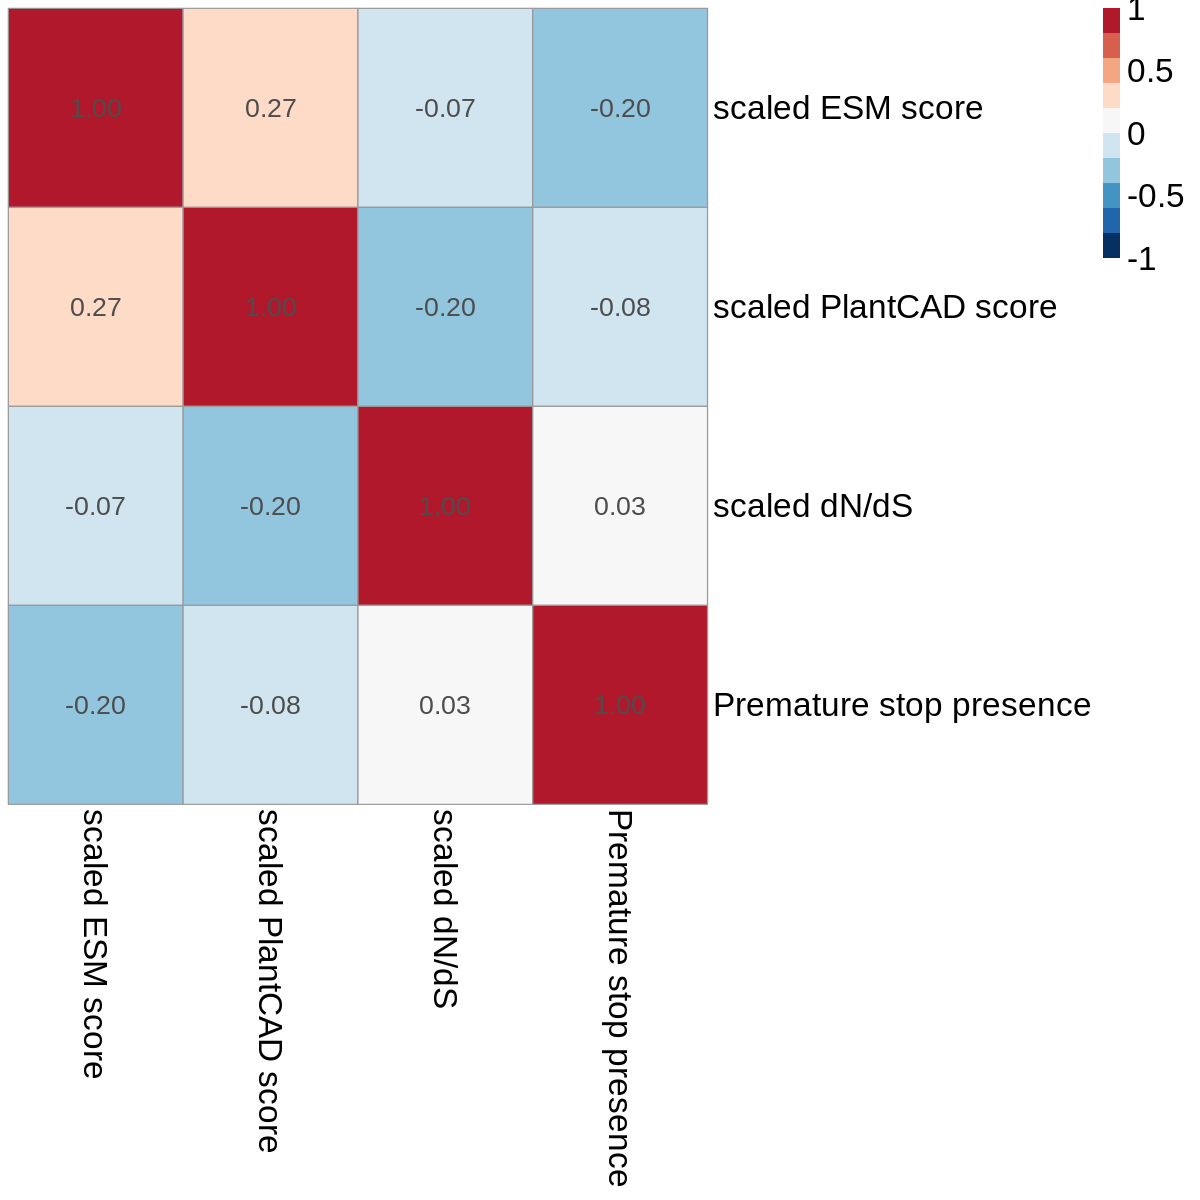

In [120]:
gc()
options(repr.plot.width=10, repr.plot.height=10)
pheatmap(rMat,cluster_row =F, cluster_col = F, display_number =T,fontsize = 20,
         color = rev(RColorBrewer::brewer.pal(11,"RdBu")),breaks = seq(-1,1,0.2))

In [121]:
pheatmap(rMat,cluster_row =F, cluster_col = F, display_number =T,fontsize = 20,
         number_color = ifelse(abs(rMat)>0.5,"white","black"),
         color = rev(RColorBrewer::brewer.pal(11,"RdBu")),breaks = seq(-1,1,0.2),
         filename = file.path(PHYLOGWAS_ROOT, "output/figure/Fig3c_v2.png"),
         width = 8.7,height = 8.7,units = "cm",res = 600)


In [76]:
tmp = testData_merged[testData_merged$groups2%in%1:5,grep('seq|scaled|group',colnames(testData_merged))]
tmp$groups3 = tmp$groups2
tmp$groups3[tmp$groups2%in%1:3] = 1

In [116]:
p1 = ggplot(testData_merged, aes(x = scaledESM, y = PMS,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 1, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "orange", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$scaledESM)) +
  scale_y_discrete(labels=c("0" = "premature stop absence", "1" = "premature stop presence"))+
#   geom_vline(xintercept = 0,col = "blue",linetype = "dotted")+
  labs(title = "",x = "Scaled ESM score",y = "")+
  xlim(c(-3,2)) +
  theme_classic() +
  theme(
      axis.text.y = element_text(size = 8),
    legend.position = "none",
    strip.text.x = element_text(size = 6)
  )

In [117]:
p2 = ggplot(tmp, aes(x = scaledPlantCAD, y = groups3,fill = ..x..)) +
  geom_density_ridges_gradient(scale = 1, rel_min_height = 0,quantiles = 2,quantile_lines = T) + 
  scale_fill_gradient2(name = "Zero-shot scores", low = "salmon", mid = "grey90", high = "white", 
                       midpoint = median(testData_merged$scaledPlantCAD)) +
  scale_y_discrete(labels=c("1" = "scaled dN/dS <95%",
                            "4" = "scaled dN/dS 95%-99%","5" = "scaled dN/dS >99%"))+
#   geom_vline(xintercept = 0,col = "blue",linetype = "dotted")+
  labs(title = "",x = "Scaled PlantCAD score",y = "")+
  ylab("") +
  xlim(c(-3,2)) +
  theme_classic() +
  theme(axis.text.y = element_text(size = 8),
    legend.position = "none",
    strip.text.x = element_text(size = 6)
  )

In [118]:
gc()
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig3d.png"),width = 8.7*1.1,height = 8.7,units = "cm",res = 600,
    pointsize = 8)
p1+p2 + plot_layout(ncol = 1, guides = "collect",heights = c(2,3))
dev.off()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,18671814,997.2,39263487,2096.9,26552986,1418.1
Vcells,6584809998,50238.2,19633324054,149790.4,16360978250,124824.4


Picking joint bandwidth of 0.0412

Picking joint bandwidth of 0.0563



pdf 
  2

## supplemental analysis

In [10]:
setDT(testData_merged)

safe_max <- function(x) {
  if (length(x) == 0 || all(is.na(x))) {
    NA_real_
  } else {
    max(x, na.rm = TRUE)
  }
}
safe_min <- function(x) {
  if (length(x) == 0 || all(is.na(x))) {
    NA_real_
  } else {
    min(x, na.rm = TRUE)
  }
}

# Then perform aggregations using data.table syntax:
agg_dt <- testData_merged[, .(
  ESM2 = safe_max(scaledESM),
  PlantCad = safe_max(scaledPlantCAD),
  PMS = safe_max(as.numeric(PMS == 0)),
  omega = safe_min(scaled.dn.ds),
  PAV = ifelse(is.na(safe_max(scaledESM)), 0, 1)
), by = .(OG, assemblyID)]

# agg_dt[,3:7] <- nafill(agg_dt[,3:7], fill = 0)

# If you need to reshape to wide format:
result <- dcast(agg_dt, assemblyID ~ OG, value.var = c("ESM2", "PlantCad", "PMS", "omega", "PAV"))
# result <- result[, ]

myX = result[,-1]
setnafill(myX, fill = 0)

myX = as.data.frame(myX)

rownames(myX) = result$assemblyID

fwrite(myX,file.path(PHYLOGWAS_ROOT, "output/functionPredictionPerOG_20251023.txt"),sep = "\t",quote = F,row.names = T)

In [59]:
myX = data.frame(fread(file.path(PHYLOGWAS_ROOT, "output/functionPredictionPerOG_20251023.txt"), header = T),row.names = 1)

In [61]:
geneLosscountPerTaxa = rowSums(1-myX[,grep("PAV",colnames(myX))])
# myX = myX[-which(geneLosscountPerTaxa>15000),]

In [63]:
which(geneLosscountPerTaxa>15000)

named integer(0)

In [ ]:
# sum(envDf$bio01_Annual_Mean_Temperature_quan50<15)
# sum(envDf$bio12_Annual_Precipitation_quan50<500)

# write.table(rownames(envDf)[envDf$bio01_Annual_Mean_Temperature_quan50<15],
#             file.path(PHYLOGWAS_ROOT, "output/coldAssembly.txt"),quote = F,row.names = F,col.names = F)
# write.table(rownames(envDf)[envDf$bio12_Annual_Precipitation_quan50<500],
#             file.path(PHYLOGWAS_ROOT, "output/aridAssembly.txt"),quote = F,row.names = F,col.names = F)


avgOmegaPerOG = tapply(testData_merged$dn.ds,testData_merged$OG,mean,na.rm =T)
varOmegaPerOG = tapply(testData_merged$dn.ds,testData_merged$OG,function(x) sd(x,na.rm =T)/mean(x,na.rm =T))
geneLosscountPerOG = colSums(1-myX[,grep("PAV",colnames(myX))])
PMScountPerOG = tapply(testData_merged$PMS,testData_merged$OG,function(x) sum(as.numeric(x)-1,na.rm =T)) # factor 0/1 -> 1/2...
# FScountPerOG = tapply(testData_merged$Frameshift,testData_merged$OG,function(x) sum(as.numeric(x),na.rm =T))

In [126]:
summary(geneLosscountPerOG)
summary(PMScountPerOG)
summary(avgOmegaPerOG)
summary(varOmegaPerOG)
quantile(geneLosscountPerOG,c(0.01,0.05,0.1,0.9,.95,0.99,.999))
quantile(PMScountPerOG,c(0.01,0.05,0.1,0.9,.95,0.99,.999))
quantile(avgOmegaPerOG,c(0.01,0.05,0.1,0.9,.95,0.99,.999))
quantile(varOmegaPerOG,c(0.01,0.05,0.1,0.9,.95,0.99,.999))

summary(as.numeric(table(testData_merged$OG)))

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    1.00   23.88    6.00  623.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.00   19.00   36.67   39.00 1721.00 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.004018 0.113058 0.165775 0.191258 0.239528 2.752540 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.08782 0.21833 0.26848 0.29285 0.33724 1.82074 

1%    5%   10%   90%   95%   99% 99.9% 
  0.0   0.0   0.0  49.8 126.0 495.0 590.0

1%      5%     10%     90%     95%     99%   99.9% 
  0.000   1.000   2.000  81.000 134.000 310.760 551.776

1%         5%        10%        90%        95%        99%      99.9% 
0.02743098 0.05714302 0.07634477 0.33114398 0.40244398 0.57875736 1.19393441

1%        5%       10%       90%       95%       99%     99.9% 
0.1374526 0.1668522 0.1837989 0.4189887 0.4891918 0.7433611 1.2119293

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  101.0   781.0   808.0   813.5   840.0  9315.0 

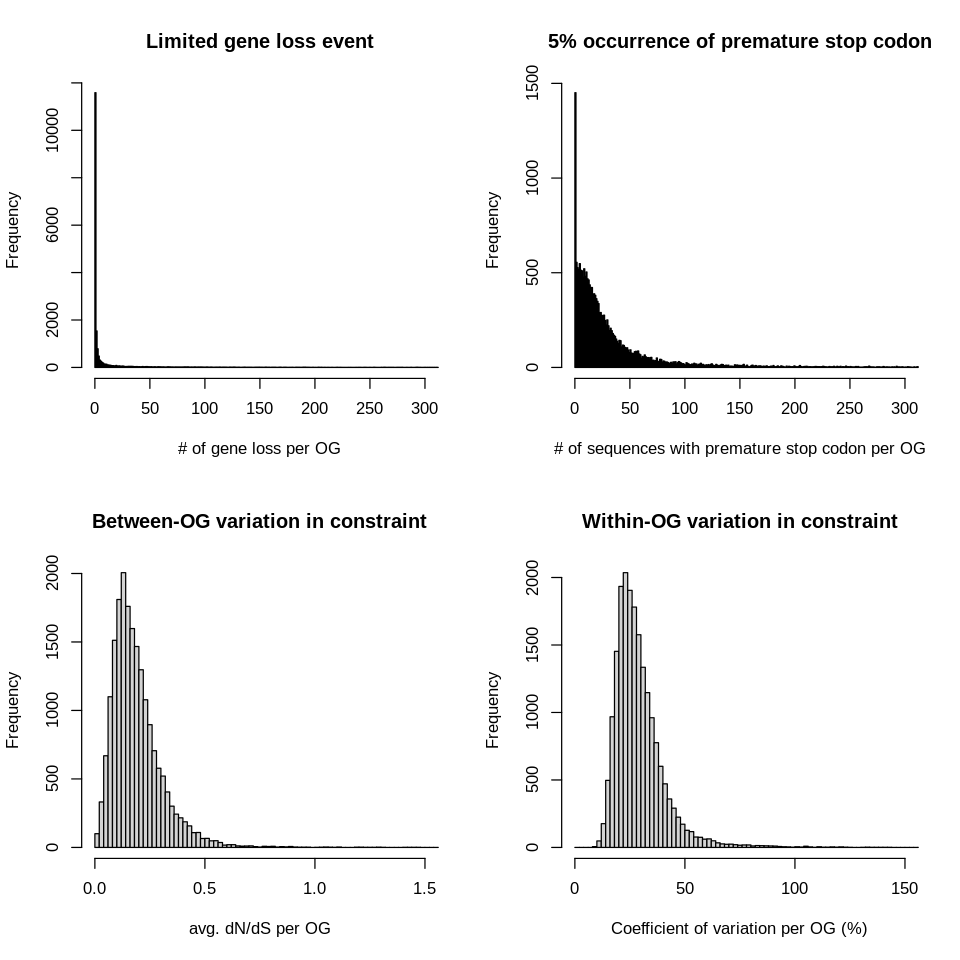

In [176]:
par(mfrow = c(2,2))
hist(geneLosscountPerOG,breaks = seq(0,650,1),xlim = c(0,300),
     main = "Limited gene loss event",xlab = "# of gene loss per OG")
hist(PMScountPerOG,breaks = seq(0,2000,1),xlim = c(0,300),
     main = "5% occurrence of premature stop codon",xlab = "# of sequences with premature stop codon per OG")
hist(avgOmegaPerOG,xlim = c(0,1.5),breaks = seq(0,4,0.02),
     main = "Between-OG variation in constraint",xlab = "avg. dN/dS per OG")
hist(varOmegaPerOG*100,xlim = c(0,150),breaks = seq(0,400,2),
     main = "Within-OG variation in constraint",xlab = "Coefficient of variation per OG (%)")

In [35]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/suppFig/suppFig_genomicPipeline_e.png"),
    width = 8,height = 7.5,units = "cm",pointsize = 6,res = 900)
par(mfrow = c(2,2))
hist(geneLosscountPerOG,breaks = seq(0,650,1),xlim = c(0,60),
     main = "Limited gene loss event",xlab = "# of gene loss per OG")
hist(PMScountPerOG,breaks = seq(0,2000,1),xlim = c(0,300),
     main = "5% occurrence of premature stop codon",xlab = "# of sequences with premature stop codon per OG")
hist(avgOmegaPerOG,xlim = c(0,1.5),breaks = seq(0,4,0.01),
     main = "Between-OG variation in constraint",xlab = "avg. dN/dS per OG")
hist(varOmegaPerOG*100,xlim = c(0,150),breaks = seq(0,400,1),
     main = "Within-OG variation in constraint",xlab = "Coefficient of variation per OG (%)")
dev.off()

pdf 
  2

In [114]:
sum(geneLosscountPerOG>495)
sum(PMScountPerOG>310)
sum(avgOmegaPerOG>.58)
sum(varOmegaPerOG>.74)

[1] 196

[1] 197

[1] 193

[1] 200

In [219]:
lostOG = list(names(PMScountPerOG)[geneLosscountPerOG>495],
              names(PMScountPerOG)[PMScountPerOG>310],
              names(PMScountPerOG)[avgOmegaPerOG>.58],
              names(PMScountPerOG)[varOmegaPerOG>.74])

In [119]:
library(topGO)

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: graph


Attaching package: ‘graph’


The following objects are masked from ‘package:ape’:

    complement, degree, edges


The following object is masked from ‘packa

In [121]:
mappingFile2 = read.table(file.path(PHYLOGWAS_ROOT, "data/OGToZm_mapping_v2.txt"))
colnames(mappingFile2) = c("ZmID","OG")
mappingFileMerged = mappingFile2[,c("OG","ZmID")]

GODB <- readMappings(file.path(PHYLOGWAS_ROOT, "data/Zm00001eb.1.fulldata_goList.txt"),IDsep = ",")
background = intersect(names(GODB),substr(mappingFileMerged$ZmID,1,15))

In [220]:
tgd1 = list()
GO_res_table = list()
for (i in 1:4){
    tmp=factor(as.integer(background%in%substr(mappingFileMerged$ZmID[mappingFileMerged$OG%in%lostOG[[i]]],1,15)))
    names(tmp)=background
    tgd1[[i]]=new( "topGOdata", ontology="BP", allGenes = tmp, nodeSize=5,annot=annFUN.gene2GO, gene2GO = GODB)
    resTopGO.classic=runTest(tgd1[[i]], algorithm = "classic", statistic = "Fisher")
    resTopGO.weight01=runTest(tgd1[[i]], algorithm = "elim", statistic = "Fisher")
    GO_res_table[[i]]=GenTable(tgd1[[i]],Fisher.classic = resTopGO.classic,Fisher.weight01=resTopGO.weight01,
                          orderBy = "Fisher.weight01",ranksOf="Fisher.classic",
                          topNodes=length(resTopGO.classic@score),numChar=100)
}


Building most specific GOs .....

	( 3729 GO terms found. )


Build GO DAG topology ..........

	( 5296 GO terms and 11198 relations. )


Annotating nodes ...............

	( 12805 genes annotated to the GO terms. )


			 -- Classic Algorithm -- 

		 the algorithm is scoring 715 nontrivial nodes
		 parameters: 
			 test statistic: fisher


			 -- Elim Algorithm -- 

		 the algorithm is scoring 715 nontrivial nodes
		 parameters: 
			 test statistic: fisher
			 cutOff: 0.01


	 Level 14:	1 nodes to be scored	(0 eliminated genes)


	 Level 13:	5 nodes to be scored	(0 eliminated genes)


	 Level 12:	12 nodes to be scored	(0 eliminated genes)


	 Level 11:	24 nodes to be scored	(0 eliminated genes)


	 Level 10:	39 nodes to be scored	(0 eliminated genes)


	 Level 9:	71 nodes to be scored	(0 eliminated genes)


	 Level 8:	75 nodes to be scored	(0 eliminated genes)


	 Level 7:	109 nodes to be scored	(0 eliminated genes)


	 Level 6:	130 nodes to be scored	(56 eliminated genes)


	 Level 5

In [224]:
topGOTab = list()
for (i in 1:4){
    GO_res_table[[i]]$foldER = GO_res_table[[i]]$Significant/GO_res_table[[i]]$Expected

    topGOTab[[i]] = subset(GO_res_table[[i]],Fisher.weight01<0.01 & Significant >1&foldER>2)
    topGOTab[[i]] = head(topGOTab[[i]][order(topGOTab[[i]]$Fisher.weight01),],5)
}
topGOTab

,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,GO:0006887,exocytosis,56,4,0.38,1,0.00053,0.00053,10.52632
2,GO:0044403,biological process involved in symbiotic interaction,44,3,0.30,4,0.00318,0.00318,10.00000
,GO.ID,Term,Annotated,Significant,Expected,Rank in Fisher.classic,Fisher.classic,Fisher.weight01,foldER
,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<chr>,<chr>,<dbl>
3,GO:0007018,microtubule-based movement,62,5,0.68,29,0.00057,0.00057,7.352941
4,GO:0007097,nuclear migration,6,2,0.07,36,0.00173,0.00173,28.571429
5,GO:0032366,intracellular sterol transport,6,2,0.07,37,0.00173,0.00173,28.571429
6,GO:0006368,transcription elongation by RNA polymerase II promoter,34,3,0.37,51,0.00597,0.00597,8.108108
7,GO:0071763,nuclear membrane organization,11,2,0.12,53,0.00612,0.00612,16.666667


In [249]:
png(file.path(PHYLOGWAS_ROOT, "output/figure/Fig2.png"),
    width = 8.7*1.5,height = 8.7*2,units = 'cm',res = 600,pointsize = 8)
par(mfcol = c(4,2),las = 1)
par(mar = c(5,5,2,2))
hist(geneLosscountPerOG,breaks = seq(0,650,1),xlim = c(0,800),border = "royalblue",col = "royalblue",
     main = "Limited gene loss event",xlab = "# of gene loss per OG")
abline(v = 495, col = "red")
hist(PMScountPerOG,breaks = seq(0,2000,1),xlim = c(0,800),border = "royalblue",col = "royalblue",
     main = "5% occurrence of premature stop codon",xlab = "# of sequences with premature stop codon per OG")
abline(v = 310, col = "red")
hist(avgOmegaPerOG,xlim = c(0,1.5),breaks = seq(0,4,0.01),border = "royalblue",col = "royalblue",
     main = "Between-OG variation in constraint",xlab = "avg. dN/dS per OG")
abline(v = 0.58, col = "red")
hist(varOmegaPerOG*100,xlim = c(0,200),breaks = seq(0,400,1),border = "royalblue",col = "royalblue",
     main = "Within-OG variation in constraint",xlab = "Coefficient of variation per OG (%)")
abline(v = 74, col = "red")

par(mar = c(5,1,2,2))
for(i in 1:4){
    bp = barplot(rev(-log10(as.numeric(topGOTab[[i]]$Fisher.weight01))),horiz = T,
                 names.arg = NULL,las = 1,xlab = "Significance",col = "lightblue",
                 main = "")
    tmpLab = sapply(rev(topGOTab[[i]]$Term),function(x) paste(strwrap(x,width = 70),collapse = "\n"))
    text(0,bp,tmpLab,col ="black",pos = 4)
}
dev.off()

pdf 
  2